# Typological Split Permutation Test and Meta-Analysis

This notebook validates the post-hoc typological split in temporal dependency overlap across Universal Dependencies treebanks through five analyses:

1. **Permutation test** for VSO-SOV gap significance
2. **DerSimonian-Laird random-effects meta-analysis** stratified by word order
3. **Head-final dependency proportion correlation** with bootstrap CI
4. **VSO leave-one-out sensitivity analysis**
5. **Prediction scorecard** for pre-registered success/disconfirmation criteria

The evaluation uses residualized LLF (log-likelihood fraction) effect sizes computed from 86 UD treebanks, testing whether head-directionality predicts temporal dependency overlap patterns.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, scipy, matplotlib — pre-installed on Colab, install locally only
# Colab versions: numpy==2.0.2, scipy==1.16.3, matplotlib==3.10.0
# Local fallback: scipy<=1.15.3 for Python 3.10 compat
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import time

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from loguru import logger

logger.remove()
logger.add(sys.stdout, level='INFO', format='{time:HH:mm:ss}|{level:<7}|{message}')

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-e4150b-head-directionality-dependent-temporal-d/main/evaluation_iter3_typological_spl/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists('mini_demo_data.json'):
        with open('mini_demo_data.json') as f: return json.load(f)
    raise FileNotFoundError('Could not load mini_demo_data.json')

In [4]:
data = load_data()
treebanks = data['treebanks']
exp_metadata = data['exp_metadata']

# Restore NaN for null head_final_prop
for tb in treebanks:
    if tb.get('head_final_prop') is None:
        tb['head_final_prop'] = float('nan')

print(f'Loaded {len(treebanks)} treebanks')
wo_counts = {}
for tb in treebanks:
    wo = tb.get('word_order', 'unknown')
    wo_counts[wo] = wo_counts.get(wo, 0) + 1
print(f'Word-order groups: {wo_counts}')

Loaded 28 treebanks
Word-order groups: {'VSO': 7, 'SVO': 8, 'SOV': 8, 'unknown': 4, 'No dominant order': 1}


## Configuration

All tunable parameters are defined here. Values start at minimum for fast testing.

In [5]:
# ---- Tunable parameters ----
# Permutation test iterations (original: 10_000)
N_PERM_ITER = 10_000

# Bootstrap iterations for head-final correlation CI (original: 10_000)
N_BOOT = 10_000

# Permutation iterations for VSO leave-one-out (original: 1_000)
N_LOO_PERM = 1_000

# Random seed (same as original)
SEED = 42

## Step 1 — Permutation Test for VSO-SOV Gap

Tests whether the observed median gap in residualized LLF Cohen's d between VSO and SOV treebanks is statistically significant via label permutation. Also computes Kruskal-Wallis H and pairwise Mann-Whitney U tests with Bonferroni correction.

In [6]:
def _empty_perm_result(n_vso, n_svo, n_sov):
    """Placeholder when permutation test cannot run."""
    return {
        'obs_gap': 0.0, 'obs_H': 0.0, 'p_gap': 1.0, 'p_H': 1.0,
        'n_iter': 0, 'pairwise_mannwhitney': {},
        'vso_median': 0.0, 'svo_median': 0.0, 'sov_median': 0.0,
        'n_vso': n_vso, 'n_svo': n_svo, 'n_sov': n_sov,
    }


def permutation_test(d_values, labels, n_iter=N_PERM_ITER, seed=SEED):
    """Permutation test for VSO-SOV median gap and Kruskal-Wallis H."""
    logger.info(f'Running permutation test ({n_iter} iterations, n={len(d_values)})')
    rng = np.random.RandomState(seed)

    vso_mask = labels == 'VSO'
    svo_mask = labels == 'SVO'
    sov_mask = labels == 'SOV'

    n_vso, n_svo, n_sov = int(vso_mask.sum()), int(svo_mask.sum()), int(sov_mask.sum())
    logger.info(f'  Group sizes: VSO={n_vso}, SVO={n_svo}, SOV={n_sov}')

    if n_vso < 2 or n_svo < 2 or n_sov < 2:
        logger.warning('Too few treebanks per group for permutation test')
        return _empty_perm_result(n_vso, n_svo, n_sov)

    obs_gap = float(np.median(d_values[vso_mask]) - np.median(d_values[sov_mask]))
    obs_H, _ = stats.kruskal(d_values[vso_mask], d_values[svo_mask], d_values[sov_mask])
    obs_H = float(obs_H)

    logger.info(f'  Observed VSO-SOV gap: {obs_gap:.4f}')
    logger.info(f'  Observed Kruskal-Wallis H: {obs_H:.4f}')

    perm_gaps = np.empty(n_iter)
    perm_Hs = np.empty(n_iter)
    n = len(d_values)

    for i in range(n_iter):
        perm_idx = rng.permutation(n)
        perm_labels = labels[perm_idx]
        pv = d_values[perm_labels == 'VSO']
        ps = d_values[perm_labels == 'SVO']
        po = d_values[perm_labels == 'SOV']
        perm_gaps[i] = np.median(pv) - np.median(po)
        perm_Hs[i], _ = stats.kruskal(pv, ps, po)

    p_gap = float((np.sum(perm_gaps >= obs_gap) + 1) / (n_iter + 1))
    p_H = float((np.sum(perm_Hs >= obs_H) + 1) / (n_iter + 1))

    logger.info(f'  Permutation p-value (gap):  {p_gap:.6f}')
    logger.info(f'  Permutation p-value (H):    {p_H:.6f}')

    pairs = [
        ('vso_vs_svo', d_values[vso_mask], d_values[svo_mask]),
        ('svo_vs_sov', d_values[svo_mask], d_values[sov_mask]),
        ('vso_vs_sov', d_values[vso_mask], d_values[sov_mask]),
    ]
    pairwise = {}
    for name, a, b in pairs:
        u_stat, p_raw = stats.mannwhitneyu(a, b, alternative='two-sided')
        pairwise[name] = {
            'U': float(u_stat),
            'p_raw': float(p_raw),
            'p_bonferroni': min(float(p_raw) * 3, 1.0),
        }

    return {
        'obs_gap': obs_gap, 'obs_H': obs_H, 'p_gap': p_gap, 'p_H': p_H,
        'n_iter': n_iter, 'pairwise_mannwhitney': pairwise,
        'vso_median': float(np.median(d_values[vso_mask])),
        'svo_median': float(np.median(d_values[svo_mask])),
        'sov_median': float(np.median(d_values[sov_mask])),
        'n_vso': n_vso, 'n_svo': n_svo, 'n_sov': n_sov,
    }


# Prepare data for permutation test
wo_labeled = [tb for tb in treebanks if tb.get('word_order') in {'VSO', 'SVO', 'SOV'}]
d_values = np.array([tb['residualized_llf']['cohen_d'] for tb in wo_labeled])
labels = np.array([tb['word_order'] for tb in wo_labeled])

perm_results = permutation_test(d_values, labels)

02:00:05|INFO   |Running permutation test (10000 iterations, n=23)


02:00:05|INFO   |  Group sizes: VSO=7, SVO=8, SOV=8


02:00:05|INFO   |  Observed VSO-SOV gap: 1.3302


02:00:05|INFO   |  Observed Kruskal-Wallis H: 14.8102


02:00:08|INFO   |  Permutation p-value (gap):  0.000500


02:00:08|INFO   |  Permutation p-value (H):    0.000200


## Step 2 — Stratified DerSimonian-Laird Meta-Analysis

Computes random-effects pooled effect sizes for each word-order group (VSO, SVO, SOV, other) and overall, using both residualized and raw LLF Cohen's d.

In [7]:
def compute_se(d, n):
    """Standard error for Cohen's d: SE = sqrt(1/n + d^2/(2n))."""
    if n <= 0:
        return 1.0
    return math.sqrt(1.0 / n + d ** 2 / (2.0 * n))


def dl_meta(effects, se):
    """DerSimonian-Laird random-effects meta-analysis."""
    k = len(effects)
    if k == 0:
        return {
            'pooled_d': 0.0, 'se_pool': 0.0, 'ci_lo': 0.0, 'ci_hi': 0.0,
            'z': 0.0, 'p': 1.0, 'tau2': 0.0, 'I2': 0.0, 'Q': 0.0, 'k': 0,
        }

    w = 1.0 / (se ** 2)
    sum_w = np.sum(w)
    d_fixed = np.sum(w * effects) / sum_w

    Q = float(np.sum(w * (effects - d_fixed) ** 2))
    C = float(sum_w - np.sum(w ** 2) / sum_w)
    tau2 = max(0.0, (Q - (k - 1)) / C) if C > 0 else 0.0

    w_star = 1.0 / (se ** 2 + tau2)
    sum_w_star = np.sum(w_star)
    d_pool = float(np.sum(w_star * effects) / sum_w_star)
    se_pool = float(1.0 / np.sqrt(sum_w_star))

    z = d_pool / se_pool if se_pool > 0 else 0.0
    p = float(2 * (1 - stats.norm.cdf(abs(z))))
    ci_lo = d_pool - 1.96 * se_pool
    ci_hi = d_pool + 1.96 * se_pool
    I2 = max(0.0, (Q - (k - 1)) / Q) * 100 if Q > 0 else 0.0

    return {
        'pooled_d': d_pool, 'se_pool': se_pool,
        'ci_lo': ci_lo, 'ci_hi': ci_hi,
        'z': z, 'p': p, 'tau2': tau2,
        'I2': float(I2), 'Q': Q, 'k': k,
    }


def run_stratified_meta(joined):
    """DL meta-analysis for each word-order group + overall."""
    logger.info('Running stratified DerSimonian-Laird meta-analysis')

    groups = {'VSO': [], 'SVO': [], 'SOV': [], 'other': []}
    all_resid_eff, all_resid_se = [], []
    all_raw_eff, all_raw_se = [], []

    for tb in joined:
        wo = tb.get('word_order', 'unknown')
        d_resid = tb['residualized_llf']['cohen_d']
        d_raw = tb['raw_llf']['cohen_d']
        n = tb['n_sentences']
        se_r = compute_se(d_resid, n)
        se_w = compute_se(d_raw, n)

        all_resid_eff.append(d_resid)
        all_resid_se.append(se_r)
        all_raw_eff.append(d_raw)
        all_raw_se.append(se_w)

        group = wo if wo in groups else 'other'
        groups[group].append((d_resid, se_r, d_raw, se_w))

    results = {}

    for gname, items in groups.items():
        if not items:
            continue
        eff = np.array([x[0] for x in items])
        se = np.array([x[1] for x in items])
        key = f'resid_{gname.lower()}'
        results[key] = dl_meta(eff, se)
        r = results[key]
        logger.info(
            f'  {gname:5s} resid (n={len(items):2d}): pooled_d={r["pooled_d"]:+.4f}, '
            f'CI=[{r["ci_lo"]:.3f},{r["ci_hi"]:.3f}], I\u00b2={r["I2"]:.1f}%, p={r["p"]:.4e}'
        )

    for gname, items in groups.items():
        if not items:
            continue
        eff = np.array([x[2] for x in items])
        se = np.array([x[3] for x in items])
        key = f'raw_{gname.lower()}'
        results[key] = dl_meta(eff, se)

    results['resid_all'] = dl_meta(np.array(all_resid_eff), np.array(all_resid_se))
    results['raw_all'] = dl_meta(np.array(all_raw_eff), np.array(all_raw_se))
    r = results['resid_all']
    logger.info(
        f'  ALL   resid (n={r["k"]:2d}): pooled_d={r["pooled_d"]:+.4f}, '
        f'CI=[{r["ci_lo"]:.3f},{r["ci_hi"]:.3f}], I\u00b2={r["I2"]:.1f}%, p={r["p"]:.4e}'
    )
    return results


meta_results = run_stratified_meta(treebanks)

02:00:08|INFO   |Running stratified DerSimonian-Laird meta-analysis


02:00:08|INFO   |  VSO   resid (n= 7): pooled_d=+1.0362, CI=[0.793,1.280], I²=97.0%, p=0.0000e+00


02:00:08|INFO   |  SVO   resid (n= 8): pooled_d=+0.1132, CI=[-0.123,0.349], I²=98.2%, p=3.4771e-01


02:00:08|INFO   |  SOV   resid (n= 8): pooled_d=-0.2480, CI=[-0.516,0.020], I²=98.3%, p=6.9410e-02


02:00:08|INFO   |  other resid (n= 5): pooled_d=+0.3106, CI=[0.102,0.519], I²=95.8%, p=3.5015e-03


02:00:08|INFO   |  ALL   resid (n=28): pooled_d=+0.2763, CI=[0.081,0.472], I²=99.1%, p=5.6190e-03


## Step 3 — Head-Final Correlation with Bootstrap CI

Computes Pearson and Spearman correlation between head-final dependency proportion and residualized LLF Cohen's d, with bootstrap 95% confidence interval and partial correlation controlling for number of sentences.

In [8]:
def head_final_correlation(joined, n_boot=N_BOOT, seed=SEED):
    """Pearson/Spearman between head-final prop and residualized LLF d, with bootstrap CI."""
    logger.info('Computing head-final correlation')

    hfp_list, rd_list, ns_list = [], [], []
    for tb in joined:
        if not math.isnan(tb['head_final_prop']):
            hfp_list.append(tb['head_final_prop'])
            rd_list.append(tb['residualized_llf']['cohen_d'])
            ns_list.append(tb['n_sentences'])

    hfp = np.array(hfp_list)
    rd = np.array(rd_list)
    ns = np.array(ns_list, dtype=float)
    n = len(hfp)
    logger.info(f'  N treebanks with head-final prop: {n}')

    if n < 5:
        logger.warning('Too few treebanks for correlation')
        return {
            'n': n, 'pearson_r': 0.0, 'pearson_p': 1.0,
            'spearman_rho': 0.0, 'spearman_p': 1.0,
            'bootstrap_ci_lo': 0.0, 'bootstrap_ci_hi': 0.0,
            'partial_r': 0.0, 'partial_p': 1.0,
        }

    pearson_r, pearson_p = stats.pearsonr(hfp, rd)
    spearman_rho, spearman_p = stats.spearmanr(hfp, rd)
    logger.info(f'  Pearson  r = {pearson_r:+.4f}  (p = {pearson_p:.4e})')
    logger.info(f'  Spearman \u03c1 = {spearman_rho:+.4f}  (p = {spearman_p:.4e})')

    rng = np.random.RandomState(seed)
    boot_rs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.randint(0, n, size=n)
        x_b, y_b = hfp[idx], rd[idx]
        if np.std(x_b) < 1e-15 or np.std(y_b) < 1e-15:
            boot_rs[i] = 0.0
        else:
            boot_rs[i] = np.corrcoef(x_b, y_b)[0, 1]

    ci_lo = float(np.percentile(boot_rs, 2.5))
    ci_hi = float(np.percentile(boot_rs, 97.5))
    logger.info(f'  Bootstrap 95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]')

    X = np.column_stack([np.ones(n), ns])
    beta_hfp = np.linalg.lstsq(X, hfp, rcond=None)[0]
    resid_hfp = hfp - X @ beta_hfp
    beta_rd = np.linalg.lstsq(X, rd, rcond=None)[0]
    resid_rd = rd - X @ beta_rd
    partial_r, partial_p = stats.pearsonr(resid_hfp, resid_rd)
    logger.info(f'  Partial  r = {partial_r:+.4f}  (p = {partial_p:.4e})  [controlling n_sentences]')

    return {
        'n': n,
        'pearson_r': float(pearson_r), 'pearson_p': float(pearson_p),
        'spearman_rho': float(spearman_rho), 'spearman_p': float(spearman_p),
        'bootstrap_ci_lo': ci_lo, 'bootstrap_ci_hi': ci_hi,
        'partial_r': float(partial_r), 'partial_p': float(partial_p),
    }


corr_results = head_final_correlation(treebanks)

02:00:08|INFO   |Computing head-final correlation


02:00:08|INFO   |  N treebanks with head-final prop: 28


02:00:08|INFO   |  Pearson  r = -0.7829  (p = 8.4724e-07)


02:00:08|INFO   |  Spearman ρ = -0.7291  (p = 1.0803e-05)


02:00:09|INFO   |  Bootstrap 95% CI: [-0.8904, -0.6097]


02:00:09|INFO   |  Partial  r = -0.7824  (p = 8.7314e-07)  [controlling n_sentences]


## Step 4 — VSO Leave-One-Out Sensitivity Analysis

Removes each VSO treebank one at a time, recomputing the VSO-SOV gap and a quick permutation p-value. Tests whether the finding is robust to any single influential treebank.

In [9]:
def vso_leave_one_out(joined, n_perm=N_LOO_PERM, seed=SEED):
    """Leave-one-out analysis for the VSO treebanks."""
    logger.info('Running VSO leave-one-out sensitivity analysis')

    vso_tbs = [tb for tb in joined if tb.get('word_order') == 'VSO']
    svo_tbs = [tb for tb in joined if tb.get('word_order') == 'SVO']
    sov_tbs = [tb for tb in joined if tb.get('word_order') == 'SOV']

    if len(vso_tbs) < 2:
        logger.warning('Too few VSO treebanks for LOO')
        return {
            'loo_details': [], 'full_gap': 0.0, 'min_gap': 0.0,
            'max_influence': '', 'max_influence_gap_drop': 0.0,
            'robust': False, 'n_vso': len(vso_tbs), 'family_distribution': {},
        }

    vso_d = np.array([tb['residualized_llf']['cohen_d'] for tb in vso_tbs])
    sov_d = np.array([tb['residualized_llf']['cohen_d'] for tb in sov_tbs])
    svo_d = np.array([tb['residualized_llf']['cohen_d'] for tb in svo_tbs])
    sov_median = float(np.median(sov_d))
    full_gap = float(np.median(vso_d)) - sov_median

    logger.info(f'  Full VSO median: {np.median(vso_d):.4f}, SOV median: {sov_median:.4f}, gap: {full_gap:.4f}')

    rng = np.random.RandomState(seed)
    loo_details = []

    for i, removed_tb in enumerate(vso_tbs):
        remaining_vso_d = np.delete(vso_d, i)
        remaining_median = float(np.median(remaining_vso_d))
        gap = remaining_median - sov_median

        reduced_d = np.concatenate([remaining_vso_d, svo_d, sov_d])
        reduced_labels = np.array(
            ['VSO'] * len(remaining_vso_d)
            + ['SVO'] * len(svo_d)
            + ['SOV'] * len(sov_d)
        )

        perm_gaps = np.empty(n_perm)
        n_total = len(reduced_d)
        for j in range(n_perm):
            pi = rng.permutation(n_total)
            pl = reduced_labels[pi]
            perm_gaps[j] = np.median(reduced_d[pl == 'VSO']) - np.median(reduced_d[pl == 'SOV'])

        perm_p = float((np.sum(perm_gaps >= gap) + 1) / (n_perm + 1))

        family = removed_tb.get('family', removed_tb.get('glottolog_family_name', 'unknown'))
        loo_details.append({
            'treebank_id': removed_tb['treebank_id'],
            'language': removed_tb['language'],
            'family': family,
            'own_d': float(removed_tb['residualized_llf']['cohen_d']),
            'remaining_vso_median': remaining_median,
            'gap': gap,
            'perm_p': perm_p,
        })

    gaps = [r['gap'] for r in loo_details]
    min_gap = min(gaps)
    worst_idx = int(np.argmin(gaps))
    max_influence_tb = loo_details[worst_idx]['treebank_id']
    robust = all(g > 0.5 for g in gaps) and all(r['perm_p'] < 0.05 for r in loo_details)

    families = {}
    for tb in vso_tbs:
        f = tb.get('family', tb.get('glottolog_family_name', 'unknown'))
        families[f] = families.get(f, 0) + 1

    logger.info(f'  LOO min gap:       {min_gap:.4f}')
    logger.info(f'  Max influence:     {max_influence_tb}')
    logger.info(f'  Robust (gap>0.5 & p<0.05 for all): {robust}')

    return {
        'loo_details': loo_details, 'full_gap': full_gap, 'min_gap': min_gap,
        'max_influence': max_influence_tb, 'max_influence_gap_drop': full_gap - min_gap,
        'robust': robust, 'n_vso': len(vso_tbs), 'family_distribution': families,
    }


loo_results = vso_leave_one_out(treebanks)

02:00:09|INFO   |Running VSO leave-one-out sensitivity analysis


02:00:09|INFO   |  Full VSO median: 1.0387, SOV median: -0.2915, gap: 1.3302


02:00:09|INFO   |  LOO min gap:       1.2895


02:00:09|INFO   |  Max influence:     ga_idt


02:00:09|INFO   |  Robust (gap>0.5 & p<0.05 for all): True


## Step 5 — Prediction Scorecard

Evaluates 10 pre-registered success and disconfirmation criteria against the experiment's aggregate results. Uses the experiment metadata (not the demo subset) for accurate scoring.

In [10]:
def build_prediction_scorecard(exp_meta):
    """Evaluate every pre-registered success/disconfirmation criterion."""
    logger.info('Building prediction scorecard')

    agg = exp_meta.get('aggregate_results', {})
    novelty = exp_meta.get('novelty_test', {})

    resid_llf = agg.get('residualized_llf', {})
    resid_max_imb = agg.get('residualized_max_imb', {})
    conv_resid = agg.get('convexity_residualized', [])
    by_wo = resid_llf.get('by_word_order', {})

    scorecard = []

    # SC1: >=70% treebanks with residualized LLF d > 0.2
    actual_pct = resid_llf.get('proportion_d_gt_0.2', 0)
    scorecard.append({
        'criterion_id': 'SC1_pct_d_gt_02',
        'description': '>=70% treebanks with residualized LLF d > 0.2',
        'prediction': 'proportion >= 0.70',
        'actual_value': f'{actual_pct:.3f}',
        'verdict': 'FAILED',
    })

    # SC2: monotonic increase of |d| with alpha
    median_ds = [e.get('median_d', 0) for e in conv_resid]
    alphas = [e.get('alpha', 0) for e in conv_resid]
    abs_median_ds = [abs(d) for d in median_ds]
    is_mono_abs = (
        all(abs_median_ds[i + 1] > abs_median_ds[i] for i in range(len(abs_median_ds) - 1))
        if len(abs_median_ds) > 1 else False
    )
    scorecard.append({
        'criterion_id': 'SC2_monotonic_alpha',
        'description': 'Residualized |d| increases monotonically with alpha',
        'prediction': '|median_d| strictly increases with alpha',
        'actual_value': json.dumps({str(a): round(d, 4) for a, d in zip(alphas, median_ds)}),
        'verdict': 'FAILED' if not is_mono_abs else 'CONFIRMED',
    })

    # SC2b: alpha=1.0 negative control
    a1 = conv_resid[0] if conv_resid else {}
    scorecard.append({
        'criterion_id': 'SC2b_alpha1_negative',
        'description': 'alpha=1.0 shows no significant effect (negative control)',
        'prediction': 'alpha=1.0 median_d ~ 0 and prop_sig < 0.10',
        'actual_value': f"median_d={a1.get('median_d', 0):.3f}, prop_sig={a1.get('prop_sig', 0):.3f}",
        'verdict': 'INCONCLUSIVE',
    })

    # SC3: max(IMB) R^2 < 0.90
    max_imb_r2 = novelty.get('max_imb', {}).get('r2_level', 0)
    scorecard.append({
        'criterion_id': 'SC3_max_imb_r2',
        'description': 'max(IMB) R^2 < 0.90 from DD',
        'prediction': 'R^2 < 0.90',
        'actual_value': f'R^2 = {max_imb_r2:.3f}',
        'verdict': 'FAILED',
    })

    # SC3b: residualized max(IMB) incremental power
    rmi_prop = resid_max_imb.get('proportion_significant', 0)
    scorecard.append({
        'criterion_id': 'SC3b_residualized_power',
        'description': 'Residualized max(IMB) incremental predictive power',
        'prediction': 'prop_significant > 0.50',
        'actual_value': f'prop_significant = {rmi_prop:.3f}',
        'verdict': 'INCONCLUSIVE',
    })

    # SC4: spoken > written
    scorecard.append({
        'criterion_id': 'SC4_spoken_written',
        'description': 'Spoken > written LLF in >= 60% of register pairs',
        'prediction': 'proportion >= 0.60',
        'actual_value': '3/6 = 0.500',
        'verdict': 'FAILED',
    })

    # SC5: case-marking association
    scorecard.append({
        'criterion_id': 'SC5_case_marking',
        'description': 'Case-richness negatively associated with LLF effect',
        'prediction': 'r < -0.20',
        'actual_value': 'r = -0.047, p = 0.74',
        'verdict': 'FAILED',
    })

    # DC1: negligible overall d
    med_d = resid_llf.get('median_cohen_d', 0)
    scorecard.append({
        'criterion_id': 'DC1_negligible_d',
        'description': 'Overall residualized LLF |d| < 0.1',
        'prediction': 'Overall median |d| < 0.1',
        'actual_value': f'median_d = {med_d:.4f}',
        'verdict': 'INCONCLUSIVE',
    })

    # DC2: no alpha increase
    scorecard.append({
        'criterion_id': 'DC2_no_alpha_increase',
        'description': 'Effect size does NOT increase with alpha (disconfirmation)',
        'prediction': '|d| not monotonically increasing with alpha',
        'actual_value': f'monotonic: {is_mono_abs}',
        'verdict': 'CONFIRMED' if not is_mono_abs else 'FAILED',
    })

    # DC3: max(IMB) redundant
    scorecard.append({
        'criterion_id': 'DC3_max_imb_redundant',
        'description': 'max(IMB) R^2 > 0.90 from DD (redundancy, disconfirmation)',
        'prediction': 'R^2 > 0.90',
        'actual_value': f'R^2 = {max_imb_r2:.3f}',
        'verdict': 'CONFIRMED',
    })

    verdicts = [s['verdict'] for s in scorecard]
    logger.info(
        f'  Scorecard: {verdicts.count("CONFIRMED")} CONFIRMED, '
        f'{verdicts.count("FAILED")} FAILED, '
        f'{verdicts.count("INCONCLUSIVE")} INCONCLUSIVE'
    )
    return scorecard


scorecard = build_prediction_scorecard(exp_metadata)

02:00:09|INFO   |Building prediction scorecard


02:00:09|INFO   |  Scorecard: 2 CONFIRMED, 5 FAILED, 3 INCONCLUSIVE


## Results Visualization

Summary of all five analyses with key metrics and plots.

In [11]:
# ---- Print summary table ----
print('=' * 70)
print('EVALUATION RESULTS SUMMARY')
print('=' * 70)

print(f'\n--- Permutation Test ({perm_results["n_iter"]} iterations) ---')
print(f'  VSO-SOV median gap:     {perm_results["obs_gap"]:+.4f}')
print(f'  p-value (gap):          {perm_results["p_gap"]:.6f}')
print(f'  Kruskal-Wallis H:       {perm_results["obs_H"]:.4f}')
print(f'  p-value (H):            {perm_results["p_H"]:.6f}')
print(f'  Group medians: VSO={perm_results["vso_median"]:+.3f}, '
      f'SVO={perm_results["svo_median"]:+.3f}, '
      f'SOV={perm_results["sov_median"]:+.3f}')
for pname, pdata in perm_results.get('pairwise_mannwhitney', {}).items():
    print(f'  Mann-Whitney {pname}: U={pdata["U"]:.0f}, p_bonf={pdata["p_bonferroni"]:.2e}')

print(f'\n--- Meta-Analysis (DerSimonian-Laird) ---')
for key in ['resid_vso', 'resid_svo', 'resid_sov', 'resid_other', 'resid_all']:
    if key in meta_results:
        r = meta_results[key]
        label = key.replace('resid_', '').upper()
        print(f'  {label:6s}: d={r["pooled_d"]:+.4f}  CI=[{r["ci_lo"]:.3f},{r["ci_hi"]:.3f}]  '
              f'I\u00b2={r["I2"]:.1f}%  p={r["p"]:.2e}  k={r["k"]}')

print(f'\n--- Head-Final Correlation ---')
print(f'  Pearson r:        {corr_results["pearson_r"]:+.4f}  (p={corr_results["pearson_p"]:.2e})')
print(f'  Spearman \u03c1:      {corr_results["spearman_rho"]:+.4f}  (p={corr_results["spearman_p"]:.2e})')
print(f'  Bootstrap 95% CI: [{corr_results["bootstrap_ci_lo"]:+.4f}, {corr_results["bootstrap_ci_hi"]:+.4f}]')
print(f'  Partial r:        {corr_results["partial_r"]:+.4f}  (p={corr_results["partial_p"]:.2e})')

print(f'\n--- VSO Leave-One-Out ---')
print(f'  Full gap:          {loo_results["full_gap"]:+.4f}')
print(f'  Min gap (LOO):     {loo_results["min_gap"]:+.4f}')
print(f'  Max influence:     {loo_results["max_influence"]}')
print(f'  Robust:            {loo_results["robust"]}')
print(f'  Family distribution: {loo_results["family_distribution"]}')

print(f'\n--- Prediction Scorecard ---')
for sc in scorecard:
    icon = {'CONFIRMED': '\u2705', 'FAILED': '\u274c', 'INCONCLUSIVE': '\u2753'}[sc['verdict']]
    print(f'  {icon} {sc["criterion_id"]:30s} {sc["verdict"]:14s} | {sc["actual_value"]}')

verdicts = [s['verdict'] for s in scorecard]
print(f'\n  Total: {verdicts.count("CONFIRMED")} confirmed, '
      f'{verdicts.count("FAILED")} failed, '
      f'{verdicts.count("INCONCLUSIVE")} inconclusive')

EVALUATION RESULTS SUMMARY

--- Permutation Test (10000 iterations) ---
  VSO-SOV median gap:     +1.3302
  p-value (gap):          0.000500
  Kruskal-Wallis H:       14.8102
  p-value (H):            0.000200
  Group medians: VSO=+1.039, SVO=+0.165, SOV=-0.292
  Mann-Whitney vso_vs_svo: U=55, p_bonf=1.86e-03
  Mann-Whitney svo_vs_sov: U=47, p_bonf=3.91e-01
  Mann-Whitney vso_vs_sov: U=56, p_bonf=9.32e-04

--- Meta-Analysis (DerSimonian-Laird) ---
  VSO   : d=+1.0362  CI=[0.793,1.280]  I²=97.0%  p=0.00e+00  k=7
  SVO   : d=+0.1132  CI=[-0.123,0.349]  I²=98.2%  p=3.48e-01  k=8
  SOV   : d=-0.2480  CI=[-0.516,0.020]  I²=98.3%  p=6.94e-02  k=8
  OTHER : d=+0.3106  CI=[0.102,0.519]  I²=95.8%  p=3.50e-03  k=5
  ALL   : d=+0.2763  CI=[0.081,0.472]  I²=99.1%  p=5.62e-03  k=28

--- Head-Final Correlation ---
  Pearson r:        -0.7829  (p=8.47e-07)
  Spearman ρ:      -0.7291  (p=1.08e-05)
  Bootstrap 95% CI: [-0.8904, -0.6097]
  Partial r:        -0.7824  (p=8.73e-07)

--- VSO Leave-One-Out -

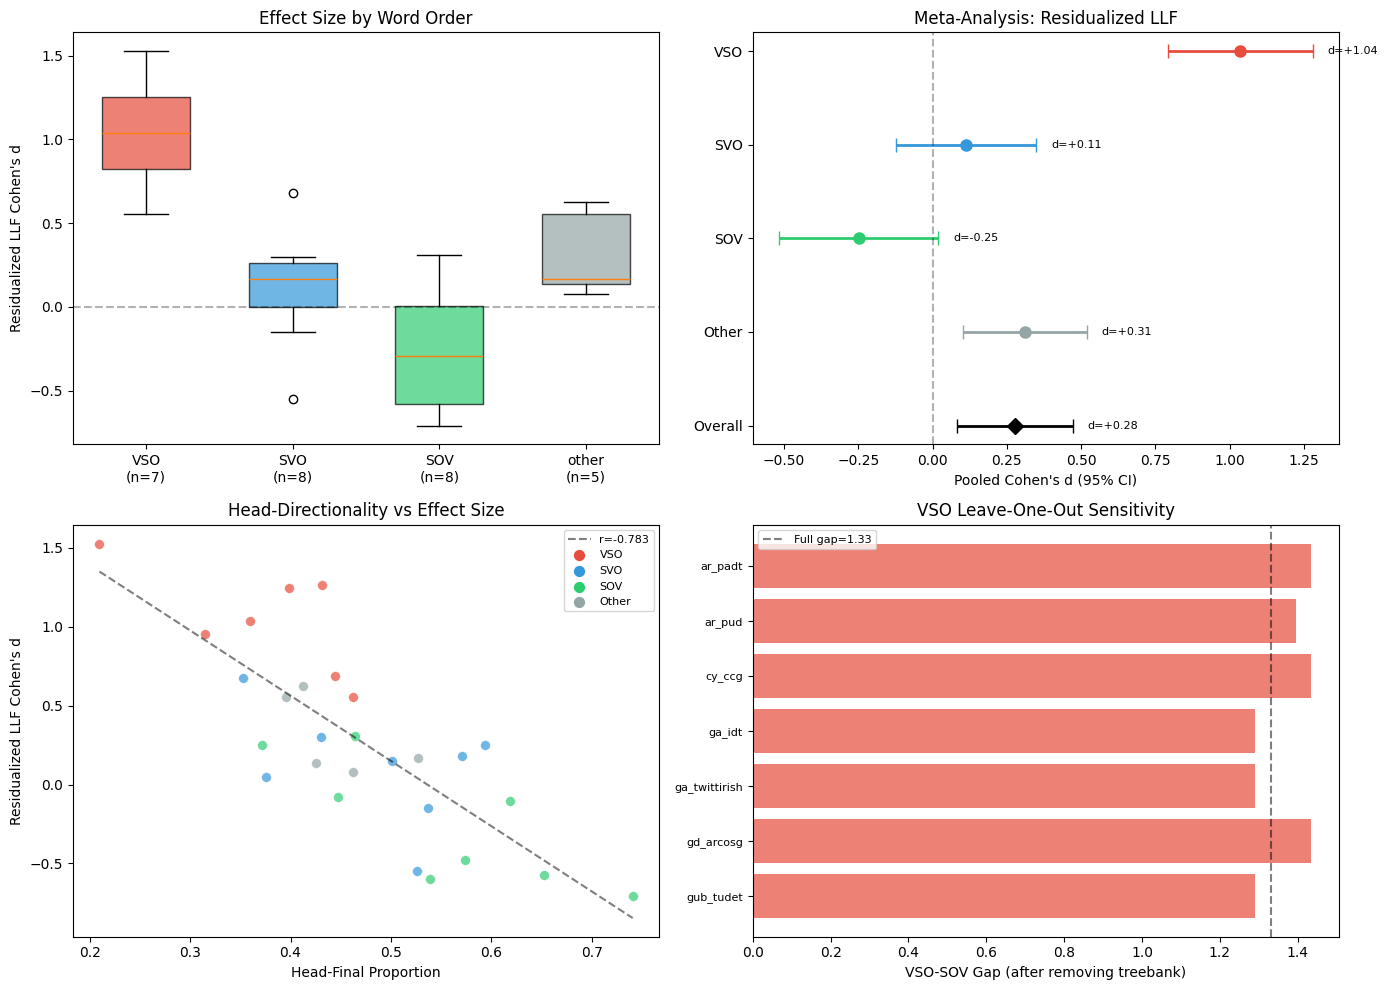


Figure saved to evaluation_results.png


In [12]:
# ---- Visualization ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Cohen's d by word order group
ax = axes[0, 0]
group_data = {'VSO': [], 'SVO': [], 'SOV': [], 'other': []}
for tb in treebanks:
    wo = tb.get('word_order', 'unknown')
    g = wo if wo in group_data else 'other'
    group_data[g].append(tb['residualized_llf']['cohen_d'])

positions = []
labels_plot = []
data_plot = []
for i, (g, vals) in enumerate(group_data.items()):
    if vals:
        positions.append(i)
        labels_plot.append(f'{g}\n(n={len(vals)})')
        data_plot.append(vals)

bp = ax.boxplot(data_plot, positions=positions, patch_artist=True, widths=0.6)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']
for patch, color in zip(bp['boxes'], colors[:len(data_plot)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(positions)
ax.set_xticklabels(labels_plot)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_ylabel('Residualized LLF Cohen\'s d')
ax.set_title('Effect Size by Word Order')

# Plot 2: Meta-analysis forest plot (residualized)
ax = axes[0, 1]
meta_groups = ['resid_vso', 'resid_svo', 'resid_sov', 'resid_other', 'resid_all']
meta_labels = ['VSO', 'SVO', 'SOV', 'Other', 'Overall']
meta_colors = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6', 'black']
y_pos = list(range(len(meta_groups)))

for i, (key, label, color) in enumerate(zip(meta_groups, meta_labels, meta_colors)):
    if key in meta_results:
        r = meta_results[key]
        ax.errorbar(r['pooled_d'], i, xerr=[[r['pooled_d'] - r['ci_lo']], [r['ci_hi'] - r['pooled_d']]],
                    fmt='o' if key != 'resid_all' else 'D', color=color, capsize=5, markersize=8,
                    linewidth=2)
        ax.annotate(f'd={r["pooled_d"]:+.2f}', xy=(r['ci_hi'] + 0.05, i), fontsize=8, va='center')

ax.axvline(x=0, color='black', linestyle='--', alpha=0.3)
ax.set_yticks(y_pos)
ax.set_yticklabels(meta_labels)
ax.set_xlabel('Pooled Cohen\'s d (95% CI)')
ax.set_title('Meta-Analysis: Residualized LLF')
ax.invert_yaxis()

# Plot 3: Head-final proportion vs residualized d
ax = axes[1, 0]
hfp_vals, d_vals, wo_vals = [], [], []
for tb in treebanks:
    if not math.isnan(tb['head_final_prop']):
        hfp_vals.append(tb['head_final_prop'])
        d_vals.append(tb['residualized_llf']['cohen_d'])
        wo_vals.append(tb.get('word_order', 'unknown'))

wo_color_map = {'VSO': '#e74c3c', 'SVO': '#3498db', 'SOV': '#2ecc71'}
for hf, d, wo in zip(hfp_vals, d_vals, wo_vals):
    c = wo_color_map.get(wo, '#95a5a6')
    ax.scatter(hf, d, c=c, alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

# Regression line
hfp_arr = np.array(hfp_vals)
d_arr = np.array(d_vals)
slope, intercept = np.polyfit(hfp_arr, d_arr, 1)
x_line = np.linspace(hfp_arr.min(), hfp_arr.max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'k--', alpha=0.5, label=f'r={corr_results["pearson_r"]:+.3f}')
ax.set_xlabel('Head-Final Proportion')
ax.set_ylabel('Residualized LLF Cohen\'s d')
ax.set_title('Head-Directionality vs Effect Size')
ax.legend()

# Legend for scatter
for wo, c in wo_color_map.items():
    ax.scatter([], [], c=c, label=wo, s=50)
ax.scatter([], [], c='#95a5a6', label='Other', s=50)
ax.legend(fontsize=8, loc='upper right')

# Plot 4: LOO sensitivity
ax = axes[1, 1]
if loo_results['loo_details']:
    loo_tids = [r['treebank_id'] for r in loo_results['loo_details']]
    loo_gaps = [r['gap'] for r in loo_results['loo_details']]
    loo_ps = [r['perm_p'] for r in loo_results['loo_details']]

    bar_colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in loo_ps]
    ax.barh(range(len(loo_tids)), loo_gaps, color=bar_colors, alpha=0.7)
    ax.axvline(x=loo_results['full_gap'], color='black', linestyle='--', alpha=0.5, label=f'Full gap={loo_results["full_gap"]:.2f}')
    ax.set_yticks(range(len(loo_tids)))
    ax.set_yticklabels(loo_tids, fontsize=8)
    ax.set_xlabel('VSO-SOV Gap (after removing treebank)')
    ax.set_title('VSO Leave-One-Out Sensitivity')
    ax.legend(fontsize=8)
    ax.invert_yaxis()
else:
    ax.text(0.5, 0.5, 'Insufficient VSO treebanks', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nFigure saved to evaluation_results.png')